### Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('cicids2017_cleaned.csv')
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


### EDA

In [3]:
df.shape

(2520751, 53)

In [4]:
df.dtypes.value_counts()

int64      32
float64    20
str         1
Name: count, dtype: int64

In [5]:
# check null values
df.isnull().sum()

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Length of Fwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Max          0
Bwd Packet Length Min          0
Bwd Packet Length Mean         0
Bwd Packet Length Std          0
Flow Bytes/s                   0
Flow Packets/s                 0
Flow IAT Mean                  0
Flow IAT Std                   0
Flow IAT Max                   0
Flow IAT Min                   0
Fwd IAT Total                  0
Fwd IAT Mean                   0
Fwd IAT Std                    0
Fwd IAT Max                    0
Fwd IAT Min                    0
Bwd IAT Total                  0
Bwd IAT Mean                   0
Bwd IAT Std                    0
Bwd IAT Max                    0
Bwd IAT Min                    0
Fwd Header Length              0
Bwd Header Length              0
Fwd Packet

In [6]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min
count,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,...,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06
mean,8.690744e+03,1.659032e+07,1.025880e+01,6.065243e+02,2.311993e+02,1.920377e+01,6.350189e+01,7.732029e+01,9.749253e+02,4.316019e+01,...,7.265707e+03,2.228741e+03,5.997266e+00,-3.082291e+03,9.152230e+04,1.719410e+05,6.542438e+04,9.337159e+06,9.763454e+06,8.892545e+06
std,1.901294e+04,3.523140e+07,7.943824e+02,1.011595e+04,7.563122e+02,6.079887e+01,1.955512e+02,2.968824e+02,2.038152e+03,7.088017e+01,...,1.459805e+04,8.924482e+03,6.743909e+02,1.149769e+06,6.858746e+05,1.084664e+06,6.106447e+05,2.484810e+07,2.561725e+07,2.458139e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-1.000000e+00,-1.000000e+00,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,2.080000e+02,2.000000e+00,1.200000e+01,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,-1.000000e+00,-1.000000e+00,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,5.062000e+04,2.000000e+00,6.600000e+01,4.000000e+01,2.000000e+00,3.625000e+01,0.000000e+00,9.700000e+01,0.000000e+00,...,2.510000e+02,0.000000e+00,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,5.332968e+06,6.000000e+00,3.320000e+02,2.020000e+02,3.700000e+01,5.200000e+01,7.419280e+01,7.460000e+02,8.200000e+01,...,8.192000e+03,2.350000e+02,3.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,1.290000e+07,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,1.953000e+04,2.896000e+03,...,6.553500e+04,6.553500e+04,2.135570e+05,1.380000e+02,1.100000e+08,1.100000e+08,1.100000e+08,1.200000e+08,1.200000e+08,1.200000e+08


In [7]:
print('Columns with negative values:')
neg_check = {}
for col in df.select_dtypes(include=np.number).columns:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        neg_check[col] = n_neg
if neg_check:
    for col, cnt in neg_check.items():
        print(f'  {col:<40} -> {cnt:,} negative values')
else:
    print('  No negative values found')

Columns with negative values:
  Flow Duration                            -> 107 negative values
  Flow Bytes/s                             -> 78 negative values
  Flow Packets/s                           -> 107 negative values
  Flow IAT Mean                            -> 107 negative values
  Flow IAT Max                             -> 107 negative values
  Flow IAT Min                             -> 2,875 negative values
  Fwd IAT Min                              -> 17 negative values
  Fwd Header Length                        -> 35 negative values
  Bwd Header Length                        -> 22 negative values
  Init_Win_bytes_forward                   -> 911,012 negative values
  Init_Win_bytes_backward                  -> 1,215,622 negative values
  min_seg_size_forward                     -> 35 negative values


In [8]:
# Check Infinite Values
print('Columns with infinite values:')
inf_check = {}
for col in df.select_dtypes(include=np.number).columns:
    n_inf = np.isinf(df[col]).sum()
    if n_inf > 0:
        inf_check[col] = n_inf
if inf_check:
    for col, cnt in inf_check.items():
        print(f'  {col:<40} -> {cnt:,} infinite values')
else:
    print('  No infinite values found')

Columns with infinite values:
  No infinite values found


In [9]:
df.duplicated().sum()

np.int64(161)

In [10]:
print("Attack Type Distribution:")
vc = df['Attack Type'].value_counts()
total = len(df)
for atk, cnt in vc.items():
    bar = '#' * int(cnt/total*40)
    print(f'  {atk:<20} {cnt:>10,}  ({cnt/total*100:5.2f}%)  {bar}')
print(f'\nImbalance ratio: {vc.max()/vc.min():.1f}x')

Attack Type Distribution:
  Normal Traffic        2,095,057  (83.11%)  #################################
  DoS                     193,745  ( 7.69%)  ###
  DDoS                    128,014  ( 5.08%)  ##
  Port Scanning            90,694  ( 3.60%)  #
  Brute Force               9,150  ( 0.36%)  
  Web Attacks               2,143  ( 0.09%)  
  Bots                      1,948  ( 0.08%)  

Imbalance ratio: 1075.5x


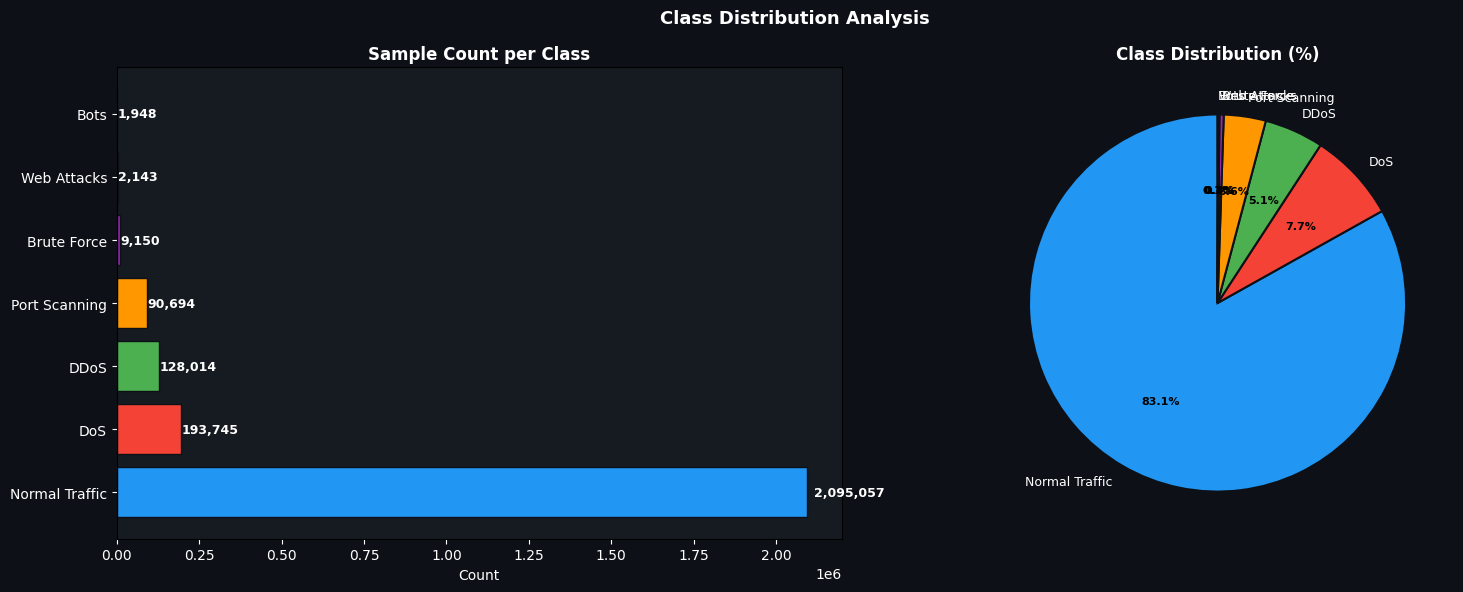

In [11]:

vc = df['Attack Type'].value_counts()

COLORS = ['#2196F3', '#F44336', '#4CAF50', '#FF9800',
          '#9C27B0', '#00BCD4', '#FFC107', '#E91E63']

fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('Class Distribution Analysis', fontsize=13,
             fontweight='bold', color='white')


ax_bar.set_facecolor('#161B22')

bars = ax_bar.barh(vc.index, vc.values,
                   color=COLORS[:len(vc)],
                   edgecolor='#0D1117')

# Add count labels next to each bar
for bar, count in zip(bars, vc.values):
    x_pos   = bar.get_width() * 1.01
    y_pos   = bar.get_y() + bar.get_height() / 2
    ax_bar.text(x_pos, y_pos, f'{count:,}',
                va='center', fontsize=9,
                fontweight='bold', color='white')

ax_bar.set_title('Sample Count per Class',
                 fontweight='bold', color='white')
ax_bar.set_xlabel('Count', color='white')
ax_bar.tick_params(colors='white')


ax_pie.set_facecolor('#0D1117')

wedges, labels, pct_labels = ax_pie.pie(
    vc.values,
    labels      = vc.index,
    colors      = COLORS[:len(vc)],
    autopct     = '%1.1f%%',
    startangle  = 90,
    wedgeprops  = {'edgecolor': '#0D1117', 'linewidth': 1.5}
)

# Style pie labels
for label in labels:
    label.set_fontsize(9)
    label.set_color('white')

for pct in pct_labels:
    pct.set_fontsize(8)
    pct.set_fontweight('bold')

ax_pie.set_title('Class Distribution (%)',
                 fontweight='bold', color='white')

plt.tight_layout()
plt.show()

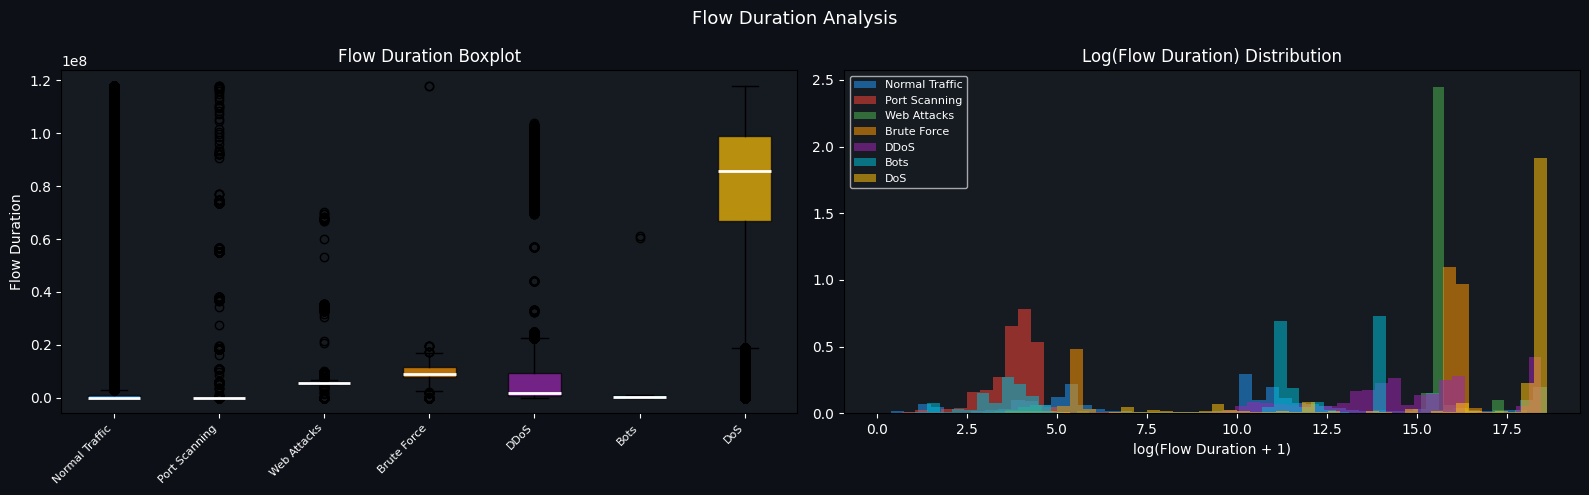

In [12]:
attack_types = df['Attack Type'].unique()
colors = ['#2196F3','#F44336','#4CAF50','#FF9800',
          '#9C27B0','#00BCD4','#FFC107','#E91E63']

fig, (left, right) = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('Flow Duration Analysis', color='white', fontsize=13)

left.set_facecolor('#161B22')

limit = df['Flow Duration'].quantile(0.99)
box_data = [
    df.loc[df['Attack Type'] == atk, 'Flow Duration'].clip(0, limit).values
    for atk in attack_types
]

bp = left.boxplot(box_data, patch_artist=True,
                  medianprops={'color': 'white', 'linewidth': 2})

for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)
    box.set_alpha(0.7)

left.set_xticklabels(attack_types, rotation=45, ha='right',
                     fontsize=8, color='white')
left.set_title('Flow Duration Boxplot', color='white')
left.set_ylabel('Flow Duration', color='white')
left.tick_params(colors='white')

right.set_facecolor('#161B22')

for i, atk in enumerate(attack_types):
    vals = np.log1p(
        df.loc[df['Attack Type'] == atk, 'Flow Duration'].clip(0).values
    )
    right.hist(vals, bins=50, alpha=0.55,
               color=colors[i % len(colors)],
               label=atk, density=True)

right.set_title('Log(Flow Duration) Distribution', color='white')
right.set_xlabel('log(Flow Duration + 1)', color='white')
right.tick_params(colors='white')
right.legend(fontsize=8, facecolor='#161B22', labelcolor='white')

plt.tight_layout()
plt.show()

### Preprocessing

In [13]:
# Fix Negative Values 
neg_fixed = []
for col in df.select_dtypes(include = np.number).columns:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        df[col] = df[col].clip(lower=0)
        neg_fixed.append((col, n_neg))
print(f'Fixed {len(neg_fixed)} columns with negative values')
for col, cnt in neg_fixed:
    print(f'  {col:<40} -> {cnt:,} values clipped to 0')

Fixed 12 columns with negative values
  Flow Duration                            -> 107 values clipped to 0
  Flow Bytes/s                             -> 78 values clipped to 0
  Flow Packets/s                           -> 107 values clipped to 0
  Flow IAT Mean                            -> 107 values clipped to 0
  Flow IAT Max                             -> 107 values clipped to 0
  Flow IAT Min                             -> 2,875 values clipped to 0
  Fwd IAT Min                              -> 17 values clipped to 0
  Fwd Header Length                        -> 35 values clipped to 0
  Bwd Header Length                        -> 22 values clipped to 0
  Init_Win_bytes_forward                   -> 911,012 values clipped to 0
  Init_Win_bytes_backward                  -> 1,215,622 values clipped to 0
  min_seg_size_forward                     -> 35 values clipped to 0


In [14]:
# Fix Infinite Values
inf_fixed = []
for col in df.select_dtypes(include=np.number).columns:
    n_inf = np.isinf(df[col]).sum()
    if n_inf > 0:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(df[col].median())
        inf_fixed.append((col, n_inf))
if inf_fixed:
    for col, cnt in inf_fixed:
        print(f'  {col:<40} -> {cnt:,} inf values fixed')
else:
    print('No infinite values to fix')

No infinite values to fix


In [15]:
# Remove Duplicates
before = len(df)
df = df.drop_duplicates()

In [16]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
clipped = 0
for col in num_cols:
    q_lo = df[col].quantile(0.005)
    q_hi = df[col].quantile(0.995)
    if q_hi > q_lo:
        df[col] = df[col].clip(lower=q_lo, upper=q_hi)
        clipped += 1
print(f'Outliers clipped in {clipped} columns (0.5-99.5 percentile)')
print(f'Dataset shape: {df.shape}')

Outliers clipped in 52 columns (0.5-99.5 percentile)
Dataset shape: (2520590, 53)


In [17]:
# Encode Target Column
from sklearn.preprocessing import StandardScaler, LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['Attack Type'])

### Feature Engineering

In [18]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'label']
new_features = []

if 'Flow Bytes/s' in df.columns and 'Flow Packets/s' in df.columns:
    df['Bytes_Per_Packet'] = df['Flow Bytes/s'] / (df['Flow Packets/s'] + 1e-6)
    new_features.append('Bytes_Per_Packet')
    print('+ Bytes_Per_Packet     -> Flow efficiency (DoS/DDoS indicator)')

if 'Fwd Packet Length Mean' in df.columns and 'Bwd Packet Length Mean' in df.columns:
    df['Fwd_Bwd_Len_Ratio'] = df['Fwd Packet Length Mean'] / (df['Bwd Packet Length Mean'] + 1e-6)
    new_features.append('Fwd_Bwd_Len_Ratio')
    print('+ Fwd_Bwd_Len_Ratio    -> Traffic asymmetry')

if 'Packet Length Mean' in df.columns and 'Packet Length Std' in df.columns:
    df['Pkt_Len_CV'] = df['Packet Length Std'] / (df['Packet Length Mean'] + 1e-6)
    new_features.append('Pkt_Len_CV')
    print('+ Pkt_Len_CV           -> Packet size regularity (PortScan indicator)')

flag_cols = [c for c in df.columns if 'Flag Count' in c]
if len(flag_cols) >= 2:
    df['Total_Flag_Count'] = df[flag_cols].sum(axis=1)
    new_features.append('Total_Flag_Count')
    print(f'+ Total_Flag_Count     -> Sum of {len(flag_cols)} TCP flags')

if 'Flow Duration' in df.columns:
    df['Flow_Duration_Log'] = np.log1p(df['Flow Duration'].clip(0))
    new_features.append('Flow_Duration_Log')
    print('+ Flow_Duration_Log    -> Log-normalized flow duration')

if 'Flow IAT Std' in df.columns and 'Flow IAT Mean' in df.columns:
    df['IAT_Regularity'] = df['Flow IAT Std'] / (df['Flow IAT Mean'] + 1e-6)
    new_features.append('IAT_Regularity')
    print('+ IAT_Regularity       -> Botnet C2 communication pattern')

if 'Destination Port' in df.columns:
    df['Port_Category'] = df['Destination Port'].apply(
        lambda p: 0 if p <= 1023 else (1 if p <= 49151 else 2))
    new_features.append('Port_Category')
    print('+ Port_Category        -> Port type (0=well-known, 1=registered, 2=dynamic)')

print(f'\nTotal new features: {len(new_features)}')
print(f'Original: {len(num_cols)}  |  After engineering: {len(num_cols)+len(new_features)}')

+ Bytes_Per_Packet     -> Flow efficiency (DoS/DDoS indicator)
+ Fwd_Bwd_Len_Ratio    -> Traffic asymmetry
+ Pkt_Len_CV           -> Packet size regularity (PortScan indicator)
+ Total_Flag_Count     -> Sum of 3 TCP flags
+ Flow_Duration_Log    -> Log-normalized flow duration
+ IAT_Regularity       -> Botnet C2 communication pattern
+ Port_Category        -> Port type (0=well-known, 1=registered, 2=dynamic)

Total new features: 7
Original: 52  |  After engineering: 59


In [19]:
# Engineered feature means per attack type
print('Mean values of engineered features by attack type:')
eng_df = df[['Attack Type'] + new_features].groupby('Attack Type').mean().round(3)
print(eng_df.to_string())

Mean values of engineered features by attack type:
                Bytes_Per_Packet  Fwd_Bwd_Len_Ratio  Pkt_Len_CV  Total_Flag_Count  Flow_Duration_Log  IAT_Regularity  Port_Category
Attack Type                                                                                                                        
Bots                      54.583              5.253       1.006             1.000              9.085           1.370          1.234
Brute Force               35.428        1512969.801       1.413             1.000             13.532           2.128          0.000
DDoS                     822.080        2180070.152       1.353             1.002             14.642           2.404          0.000
DoS                      795.756        2086887.656       1.843             1.001             16.783           2.987          0.000
Normal Traffic           121.361        3974540.121       0.818             0.569             10.150           1.366          0.366
Port Scanning            

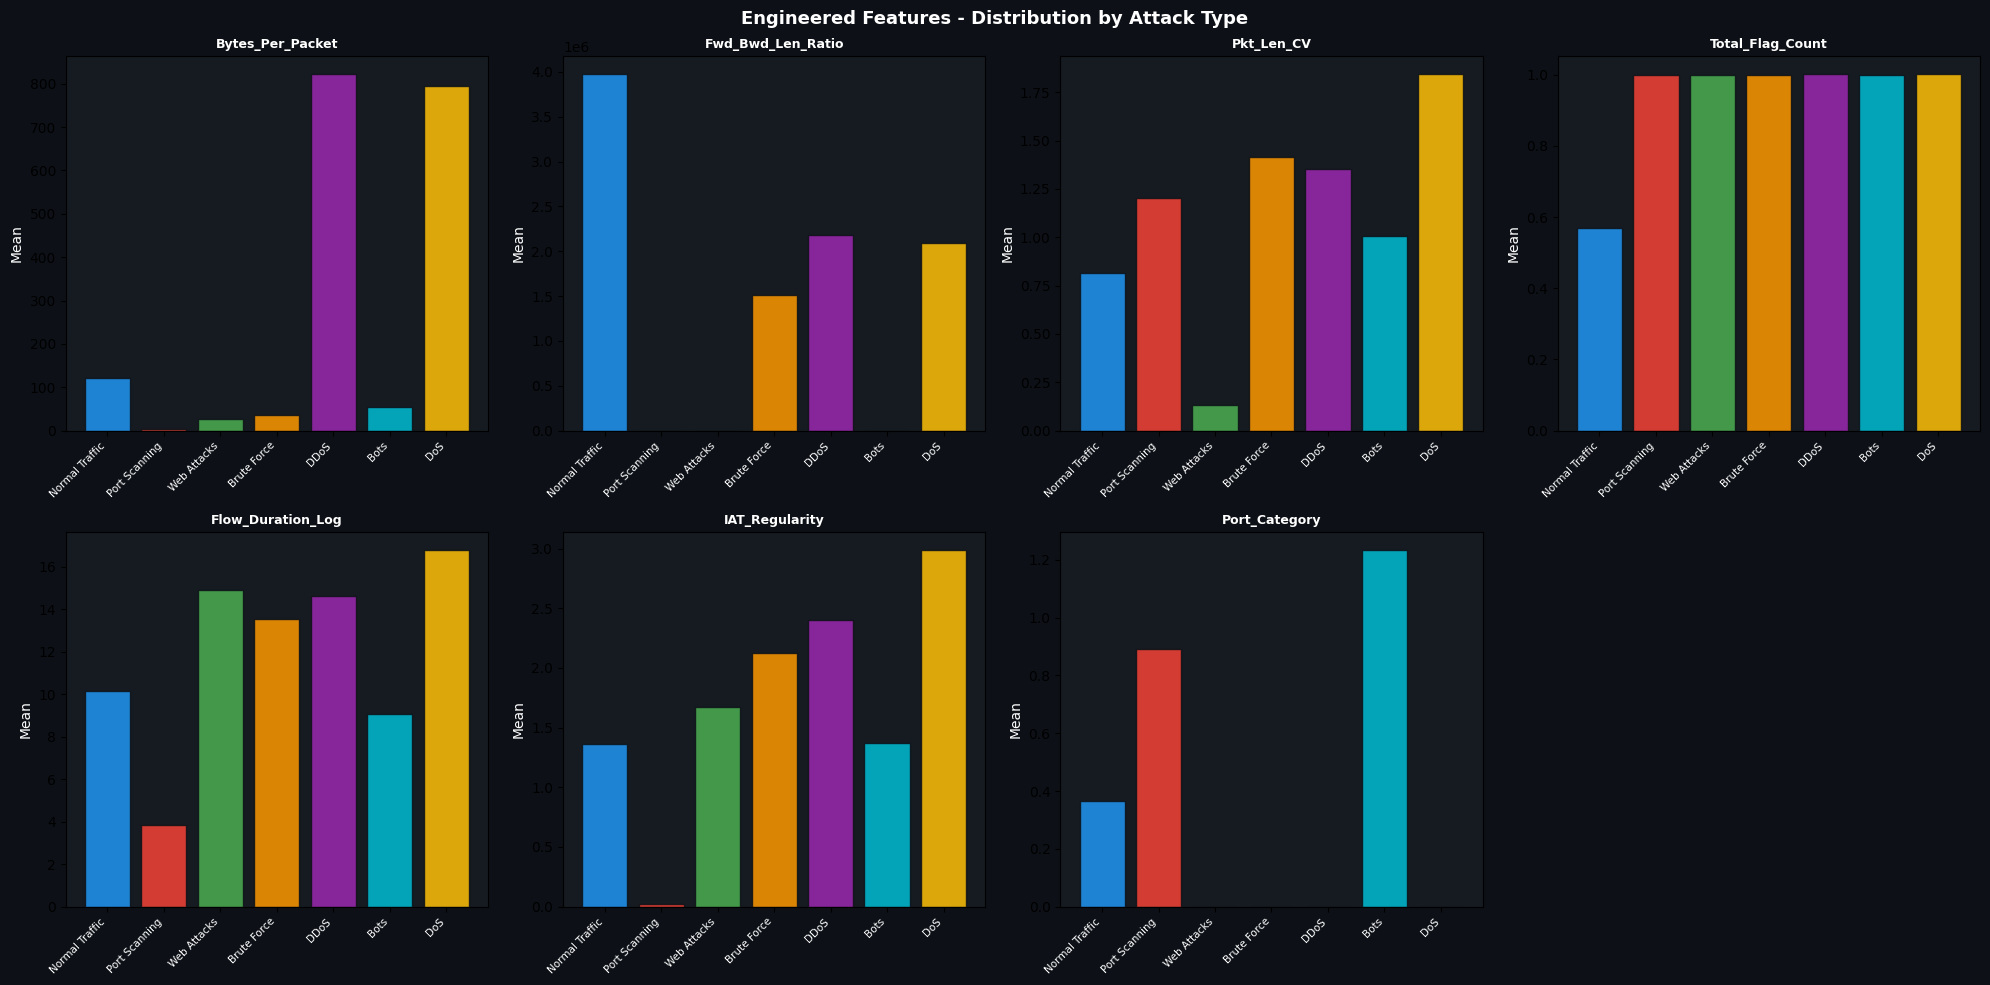

In [20]:
# Plot engineered features
COLORS = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#00BCD4','#FFC107','#E91E63']
attack_types = list(df['Attack Type'].unique())

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('Engineered Features - Distribution by Attack Type',
             fontsize=13, fontweight='bold', color='white')
axes = axes.flatten()

for ax, feat in zip(axes[:len(new_features)], new_features):
    ax.set_facecolor('#161B22')
    means = [df.loc[df['Attack Type']==atk, feat].mean() for atk in attack_types]
    bars = ax.bar(range(len(attack_types)), means,
                  color=COLORS[:len(attack_types)], edgecolor='#0D1117', alpha=0.85)
    ax.set_title(feat, fontweight='bold', fontsize=9, color='white')
    ax.set_xticks(range(len(attack_types)))
    ax.set_xticklabels(attack_types, rotation=45, ha='right', fontsize=7.5, color='white')
    ax.set_ylabel('Mean', color='white')

for ax in axes[len(new_features):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Feature Selection  

In [21]:
# Prepare data 
all_num = df.select_dtypes(include=np.number).columns.tolist()
feature_cols = [c for c in all_num if c != 'label']

# Final cleanup
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
for col in feature_cols:
    df[col] = df[col].fillna(df[col].median())

sample_size = min(100_000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)
X_s = df_sample[feature_cols].values
y_s = df_sample['label'].values
print(f'Feature selection on {sample_size:,} sample rows x {len(feature_cols)} features')

Feature selection on 100,000 sample rows x 59 features


In [22]:
# Mutual Information
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

mi_scores = mutual_info_classif(X_s, y_s, random_state=42, n_jobs=-1)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)
print('Top 10 features by Mutual Information:')
for feat, score in mi_series.head(10).items():
    print(f'  {feat:<38} {score:.4f}')

Top 10 features by Mutual Information:
  Average Packet Size                    0.5246
  Bytes_Per_Packet                       0.5120
  Packet Length Mean                     0.4964
  Packet Length Std                      0.4948
  Packet Length Variance                 0.4935
  Bwd Packet Length Mean                 0.4540
  Total Length of Fwd Packets            0.4413
  Subflow Fwd Bytes                      0.4404
  Bwd Packet Length Max                  0.4245
  Max Packet Length                      0.4081


In [23]:
# Random Forest Importance
from sklearn.ensemble import RandomForestClassifier

rf_feat = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_feat.fit(X_s, y_s)
rf_imp = pd.Series(rf_feat.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('Top 10 features by RF importance:')
for feat, imp in rf_imp.head(10).items():
    bar = '#' * int(imp * 300)
    print(f'  {feat:<38} {imp:.4f}  {bar}')

Top 10 features by RF importance:
  Bwd Packet Length Mean                 0.0864  #########################
  Packet Length Std                      0.0640  ###################
  Bwd Packet Length Std                  0.0487  ##############
  Packet Length Variance                 0.0485  ##############
  Bytes_Per_Packet                       0.0454  #############
  Total Length of Fwd Packets            0.0433  ############
  Average Packet Size                    0.0405  ############
  Subflow Fwd Bytes                      0.0404  ############
  Bwd Packet Length Max                  0.0380  ###########
  Packet Length Mean                     0.0351  ##########


In [24]:
# ANOVA F-test
k = min(30, len(feature_cols))
sel = SelectKBest(score_func=f_classif, k=k)
sel.fit(X_s, y_s)
f_series = pd.Series(sel.scores_, index=feature_cols).sort_values(ascending=False)
print('Top 10 features by ANOVA:')
for feat, score in f_series.head(10).items():
    print(f'  {feat:<38} {score:>12,.1f}')

Top 10 features by ANOVA:
  Bwd Packet Length Std                      20,683.0
  Fwd IAT Std                                19,312.9
  Bwd Packet Length Mean                     19,143.2
  Bwd Packet Length Max                      18,882.7
  Idle Mean                                  16,846.0
  Idle Min                                   16,843.0
  Packet Length Std                          16,406.9
  Idle Max                                   15,854.1
  Flow IAT Max                               15,428.4
  Fwd IAT Max                                15,327.3


In [25]:
TOP_N = 30
top_mi = set(mi_series.head(TOP_N).index)
top_rf = set(rf_imp.head(TOP_N).index)
top_f  = set(f_series.head(TOP_N).index)
selected = list((top_mi & top_rf) | (top_mi & top_f) | (top_rf & top_f))
if len(selected) < 15:
    selected = list(rf_imp.head(25).index)

print(f'Feature Selection Result:')
print(f'  Total (after engineering) : {len(feature_cols)}')
print(f'  Top-{TOP_N} by MI          : {len(top_mi)}')
print(f'  Top-{TOP_N} by RF          : {len(top_rf)}')
print(f'  Top-{TOP_N} by ANOVA       : {len(top_f)}')
print(f'  FINAL selected (>=2 votes): {len(selected)}')
print(f'\nSelected features:')
for i, feat in enumerate(sorted(selected), 1):
    print(f'  {i:2}. {feat}')

Feature Selection Result:
  Total (after engineering) : 59
  Top-30 by MI          : 30
  Top-30 by RF          : 30
  Top-30 by ANOVA       : 30
  FINAL selected (>=2 votes): 32

Selected features:
   1. Average Packet Size
   2. Bwd Header Length
   3. Bwd Packet Length Max
   4. Bwd Packet Length Mean
   5. Bwd Packet Length Std
   6. Bwd Packets/s
   7. Bytes_Per_Packet
   8. Destination Port
   9. Flow Bytes/s
  10. Flow Duration
  11. Flow IAT Max
  12. Flow_Duration_Log
  13. Fwd Header Length
  14. Fwd IAT Max
  15. Fwd IAT Mean
  16. Fwd IAT Std
  17. Fwd IAT Total
  18. Fwd Packet Length Max
  19. Fwd Packet Length Mean
  20. Fwd_Bwd_Len_Ratio
  21. IAT_Regularity
  22. Idle Max
  23. Idle Mean
  24. Init_Win_bytes_backward
  25. Max Packet Length
  26. PSH Flag Count
  27. Packet Length Mean
  28. Packet Length Std
  29. Packet Length Variance
  30. Pkt_Len_CV
  31. Subflow Fwd Bytes
  32. Total Length of Fwd Packets


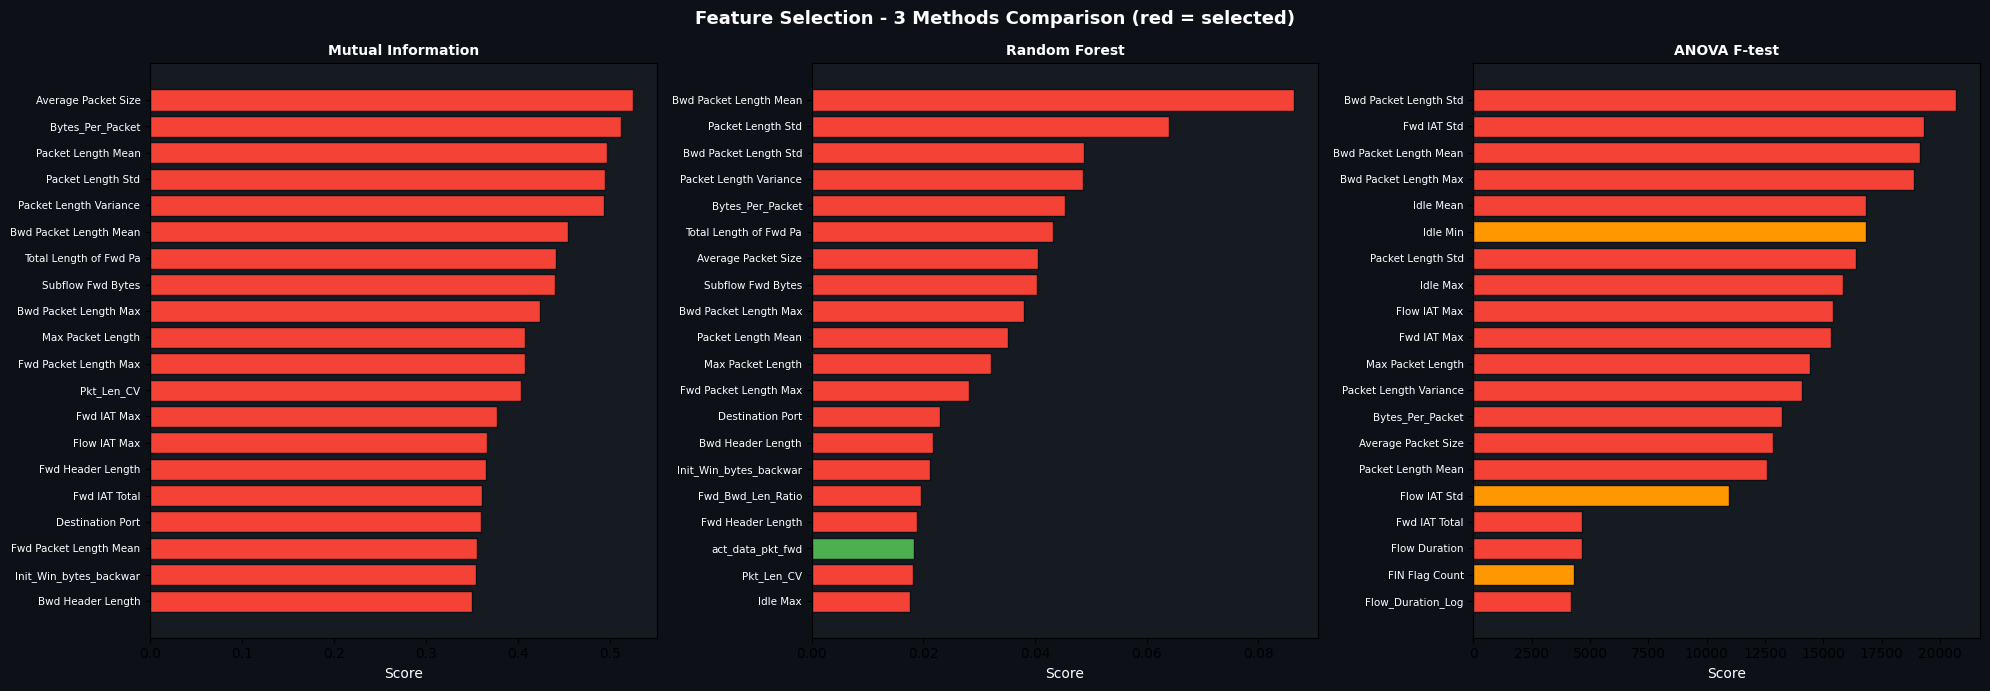

In [26]:
# Feature importance plot
COLORS3 = ['#2196F3','#4CAF50','#FF9800']
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('Feature Selection - 3 Methods Comparison (red = selected)',
             fontsize=13, fontweight='bold', color='white')

methods = [
    ('Mutual Information', mi_series.head(20), COLORS3[0]),
    ('Random Forest',      rf_imp.head(20),    COLORS3[1]),
    ('ANOVA F-test',       f_series.head(20),  COLORS3[2]),
]

for ax, (title, series, color) in zip(axes, methods):
    ax.set_facecolor('#161B22')
    s = series.sort_values()
    bar_colors = ['#F44336' if f in selected else color for f in s.index]
    ax.barh(range(len(s)), s.values, color=bar_colors, edgecolor='#0D1117')
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels([f[:22] for f in s.index], fontsize=7.5, color='white')
    ax.set_title(title, fontweight='bold', fontsize=10, color='white')
    ax.set_xlabel('Score', color='white')

plt.tight_layout()
plt.show()

In [27]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_all = df[selected].values
y_all = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_all
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   
X_test  = scaler.transform(X_test)        

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print('Leakage-free split: OK')

# Save processed dataset
df_save = df[selected + ['Attack Type', 'label']].copy()
df_save.to_csv('astra_processed_dataset.csv', index=False)

Train: 2,016,472 | Test: 504,118
Leakage-free split: OK
